1. Create API call to extract gov data
Link to Austender Website: https://www.tenders.gov.au/Reports/CnPublishedForm


Website to read Json Format: https://jsonformatter.curiousconcept.com/

If json contains "next" under links. then this means the returned data from the API is not compelte. Another call needs to be made to the url in the next section to return the additional data, until there is no next section. Use this as a criteria to loop through and apply the function. 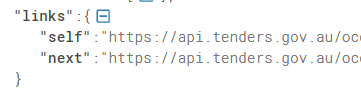

API Reference Data: https://github.com/austender/austender-ocds-api/tree/master

In [49]:
#Extracting the data from the API 

import requests
import json

start_date = '2026-06-01T00:00:00Z'
end_date = '2026-06-02T23:59:59Z'

url = f'https://api.tenders.gov.au/ocds/findByDates/contractPublished/{start_date}/{end_date}'

response = requests.get(url)
data = response.json()


In [51]:
def read_austender_data(start,end):
    import requests
    import json

    start_date = start
    end_date = end

    url = f'https://api.tenders.gov.au/ocds/findByDates/contractPublished/{start_date}/{end_date}'

    response = requests.get(url)
    data = response.json()
    return data



In [45]:
def read_more_austender_data(url):
    import requests
    import json

    response = requests.get(url)
    data = response.json()
    return data

In [52]:
begin_period = '2026-06-01T00:00:00Z'
end_period = '2026-06-02T23:59:59Z'


austender_data = read_austender_data(begin_period,end_period)

In [53]:
print(type(austender_data))
print(austender_data.keys() if isinstance(austender_data,dict) else 'Not a dict')
#print(json.dumps(response.json(),indent=2))

<class 'dict'>
dict_keys(['uri', 'publisher', 'publishedDate', 'license', 'version', 'releases', 'extensions', 'links'])


In [66]:
#If there are only 1 link then 'links' don't appear in the json

pages = []

begin_period = '2026-06-01T00:00:00Z'
end_period = '2026-07-02T23:59:59Z'


current = read_austender_data(begin_period,end_period)

while True:
    pages.append(current)

    links = current.get('links',{})
    next_url = links.get('next')

    if not next_url:
        break

    current = read_more_austender_data(next_url)


In [78]:
def pandas_data_frame(data_list):
    '''Create a flat file for the dataframe'''


    import pandas as pd
    rows = []

    for page in data_list:
        for release in page.get('releases',[]):

            ocid = release.get('ocid')
            tender = release.get('tender',{})

            procurement_method = tender.get('procurementMethod')

            # Parties (supplier + procuring entity)
            parties = release.get('parties',[])

            # Awards (supplier info lives here too)
            awards = release.get('awards',[])

            # Contracts (value, UNSPSC, dates)
            contracts = release.get('contracts',[])

            for contract in contracts:
                contract_id = contract.get('id')
                contract_title = contract.get('title')
                contract_description = contract.get('description')

                #Contract Amounts
                value = contract.get('value',{})
                amount = value.get('amount')
                currency = value.get('currency')

                #Periods
                period = contract.get('period',{})
                start_date = period.get('startDate')
                end_date = period.get('endDate')

                #UNSPSC classification
                unspsc = None
                items = contract.get('items',[])
                for item in items:
                    classification = item.get('classification',{})
                    unspsc = classification.get('id')
                    break
                 

                #government agencies default
                agency_name = None
            

                for p in parties:
                    roles = p.get('roles',[])
                    if 'procuringEntity' in roles:
                        agency_name = p.get('name')
                        break
                
                #Suppliers
                supplier_name = None
                supplier_abn = None
                locality = None
                region = None
                postal = None
                country = None

                if awards:
                    suppliers = awards[0].get('suppliers',[])
                    if suppliers:
                        supplier_name = suppliers[0].get('name')

                        for p in parties:
                            if p.get('name') == supplier_name:
                                address = p.get('address',{})
                                locality = address.get('locality')
                                region = address.get('region')
                                postal = address.get('postalCode')
                                country = address.get('countryName')
                                break


                rows.append({
                    'ocid':ocid,
                    'contract_id':contract_id,
                    'contract_title':contract_title,
                    'contract_description':contract_description,
                    'supplier_name':supplier_name,
                    'unspsc':unspsc,
                    'amount':amount,
                    'start_date':start_date,
                    'end_date':end_date,
                    'locality':locality,
                    'region':region,
                    'postal':postal,
                    'country':country,
                    'procurement_method':procurement_method,
                    'agency_name':agency_name
                    })


    df = pd.DataFrame(rows)
    return df

In [79]:
pandas_data_frame(pages)

,ocid,contract_id,contract_title,contract_description,supplier_name,unspsc,amount,start_date,end_date,locality,region,postal,country,procurement_method,agency_name
0,prod-9de8c9f503f24248a92fe471dbd37a20,CN4255715,005598,LH - ETG - Test Analyst (5 of 8)\n,INDIGITISE PTY LTD,80111600,297660.00,2026-06-14T14:00:00Z,2027-06-29T14:00:00Z,Canberra,ACT,2914,AUSTRALIA,open,Australian Electoral Commission
1,prod-fbbd1e8e101f47c5ab7b7e2b05702a89,CN4254489,PROC-5740,Temporary Personnel,Leaders IT Services Pty Ltd,80111700,372947.60,2026-06-30T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2000,AUSTRALIA,open,Future Fund Management Agency
2,prod-bce71172fedc4b608f916f5cdf963e9d,CN4257295,C18032,Corporate Courses for Influence Negotiation an...,YELLOW EDGE PTY LTD,86000000,16500.00,2026-06-30T14:00:00Z,2026-12-30T13:00:00Z,BARTON,ACT,2600,AUSTRALIA,open,"Department of Agriculture, Fisheries and Forestry"
3,prod-b478bf342560411aa1eb1523bd504067,CN4257296,C18013,Residential Lease,YARDIZE PTY LTD,80131501,34892.86,2026-08-14T14:00:00Z,2027-08-13T14:00:00Z,PORT HEADLAND,WA,6721,AUSTRALIA,limited,"Department of Agriculture, Fisheries and Forestry"
4,prod-60be42fbe416418f89d47edd25ddf3ed,CN4257287,0042005486,Employee Assistance Program,Converge International Incorporatin,80110000,450000.00,2026-06-30T14:00:00Z,2027-06-30T14:00:00Z,Melbourne,VIC,3000,Australia,open,Attorney-General's Department
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7156,prod-7e5791f9ca674e01b6e239877eae79a9,CN4245709,AC3051,Analyst IT Service Desk (LH-06238-MTP),MTP Services Pty Ltd,80111600,80639.20,2026-06-07T14:00:00Z,2026-12-06T13:00:00Z,Fyshwick,ACT,2609,AUSTRALIA,open,Australian Transaction Reports and Analysis Ce...
7157,prod-ee43b1b92c884f5a9d61ee50799aaa63,CN4245706,SCO002923-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
7158,prod-1c749af511044586a7c73eb79289985c,CN4245707,SCO002888-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
7159,prod-2e253c4485f44c42bd4d3a90b16a9c2c,CN4245704,SCO002914-0,Introduction and Placement Services,TALENT INTERNATIONAL HOLDINGS PTY LTD,80111600,50000.00,2026-05-31T14:00:00Z,2027-03-30T13:00:00Z,Deakin,ACT,2600,AUSTRALIA,open,Australian Financial Security Authority


In [67]:
#Create a flat file for the dataframe

import pandas as pd
rows = []

for page in pages:
    for release in page.get('releases',[]):

        ocid = release.get('ocid')
        tender = release.get('tender',{})

        procurement_method = tender.get('procurementMethod')

        # Parties (supplier + procuring entity)
        parties = release.get('parties',[])

        # Awards (supplier info lives here too)
        awards = release.get('awards',[])

        # Contracts (value, UNSPSC, dates)
        contracts = release.get('contracts',[])

        for contract in contracts:
            contract_id = contract.get('id')
            contract_title = contract.get('title')
            contract_description = contract.get('description')

            #Contract Amounts
            value = contract.get('value',{})
            amount = value.get('amount')
            currency = value.get('currency')

            #Periods
            period = contract.get('period',{})
            start_date = period.get('startDate')
            end_date = period.get('endDate')

            #UNSPSC classification
            unspsc = None
            items = contract.get('items',[])
            for item in items:
                classification = item.get('classification',{})
                unspsc = classification.get('id')
                break

            

        


            #government agencies default
            agency_name = None
        

            for p in parties:
                roles = p.get('roles',[])
                if 'procuringEntity' in roles:
                    agency_name = p.get('name')
                    break



            
            #Suppliers
            supplier_name = None
            supplier_abn = None
            locality = None
            region = None
            postal = None
            country = None

            if awards:
                suppliers = awards[0].get('suppliers',[])
                if suppliers:
                    supplier_name = suppliers[0].get('name')

                    for p in parties:
                        if p.get('name') == supplier_name:
                            address = p.get('address',{})
                            locality = address.get('locality')
                            region = address.get('region')
                            postal = address.get('postalCode')
                            country = address.get('countryName')
                            break


            rows.append({
                'ocid':ocid,
                'contract_id':contract_id,
                'contract_title':contract_title,
                'contract_description':contract_description,
                'supplier_name':supplier_name,
                'unspsc':unspsc,
                'amount':amount,
                'start_date':start_date,
                'end_date':end_date,
                'locality':locality,
                'region':region,
                'postal':postal,
                'country':country,
                'procurement_method':procurement_method,
                'agency_name':agency_name
                })


df = pd.DataFrame(rows)
df

,ocid,contract_id,contract_title,contract_description,supplier_name,unspsc,amount,start_date,end_date,locality,region,postal,country,procurement_method,agency_name
0,prod-9de8c9f503f24248a92fe471dbd37a20,CN4255715,005598,LH - ETG - Test Analyst (5 of 8)\n,INDIGITISE PTY LTD,80111600,297660.00,2026-06-14T14:00:00Z,2027-06-29T14:00:00Z,Canberra,ACT,2914,AUSTRALIA,open,Australian Electoral Commission
1,prod-fbbd1e8e101f47c5ab7b7e2b05702a89,CN4254489,PROC-5740,Temporary Personnel,Leaders IT Services Pty Ltd,80111700,372947.60,2026-06-30T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2000,AUSTRALIA,open,Future Fund Management Agency
2,prod-bce71172fedc4b608f916f5cdf963e9d,CN4257295,C18032,Corporate Courses for Influence Negotiation an...,YELLOW EDGE PTY LTD,86000000,16500.00,2026-06-30T14:00:00Z,2026-12-30T13:00:00Z,BARTON,ACT,2600,AUSTRALIA,open,"Department of Agriculture, Fisheries and Forestry"
3,prod-b478bf342560411aa1eb1523bd504067,CN4257296,C18013,Residential Lease,YARDIZE PTY LTD,80131501,34892.86,2026-08-14T14:00:00Z,2027-08-13T14:00:00Z,PORT HEADLAND,WA,6721,AUSTRALIA,limited,"Department of Agriculture, Fisheries and Forestry"
4,prod-60be42fbe416418f89d47edd25ddf3ed,CN4257287,0042005486,Employee Assistance Program,Converge International Incorporatin,80110000,450000.00,2026-06-30T14:00:00Z,2027-06-30T14:00:00Z,Melbourne,VIC,3000,Australia,open,Attorney-General's Department
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7156,prod-7e5791f9ca674e01b6e239877eae79a9,CN4245709,AC3051,Analyst IT Service Desk (LH-06238-MTP),MTP Services Pty Ltd,80111600,80639.20,2026-06-07T14:00:00Z,2026-12-06T13:00:00Z,Fyshwick,ACT,2609,AUSTRALIA,open,Australian Transaction Reports and Analysis Ce...
7157,prod-ee43b1b92c884f5a9d61ee50799aaa63,CN4245706,SCO002923-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
7158,prod-1c749af511044586a7c73eb79289985c,CN4245707,SCO002888-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
7159,prod-2e253c4485f44c42bd4d3a90b16a9c2c,CN4245704,SCO002914-0,Introduction and Placement Services,TALENT INTERNATIONAL HOLDINGS PTY LTD,80111600,50000.00,2026-05-31T14:00:00Z,2027-03-30T13:00:00Z,Deakin,ACT,2600,AUSTRALIA,open,Australian Financial Security Authority


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7161 entries, 0 to 7160
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ocid                  7161 non-null   object
 1   contract_id           7161 non-null   object
 2   contract_title        7111 non-null   object
 3   contract_description  7161 non-null   object
 4   supplier_name         7161 non-null   object
 5   unspsc                7161 non-null   object
 6   amount                7161 non-null   object
 7   start_date            7161 non-null   object
 8   end_date              7161 non-null   object
 9   locality              7161 non-null   object
 10  region                7161 non-null   object
 11  postal                7159 non-null   object
 12  country               7161 non-null   object
 13  procurement_method    7161 non-null   object
 14  agency_name           7161 non-null   object
dtypes: object(15)
memory usage: 839.3+ KB


In [69]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')



In [70]:
df['amount'] = pd.to_numeric(df['amount'],errors='coerce')

In [71]:
df

,ocid,contract_id,contract_title,contract_description,supplier_name,unspsc,amount,start_date,end_date,locality,region,postal,country,procurement_method,agency_name
0,prod-9de8c9f503f24248a92fe471dbd37a20,CN4255715,005598,LH - ETG - Test Analyst (5 of 8)\n,INDIGITISE PTY LTD,80111600,297660.00,2026-06-14T14:00:00Z,2027-06-29T14:00:00Z,Canberra,ACT,2914,AUSTRALIA,open,Australian Electoral Commission
1,prod-fbbd1e8e101f47c5ab7b7e2b05702a89,CN4254489,PROC-5740,Temporary Personnel,Leaders IT Services Pty Ltd,80111700,372947.60,2026-06-30T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2000,AUSTRALIA,open,Future Fund Management Agency
2,prod-bce71172fedc4b608f916f5cdf963e9d,CN4257295,C18032,Corporate Courses for Influence Negotiation an...,YELLOW EDGE PTY LTD,86000000,16500.00,2026-06-30T14:00:00Z,2026-12-30T13:00:00Z,BARTON,ACT,2600,AUSTRALIA,open,"Department of Agriculture, Fisheries and Forestry"
3,prod-b478bf342560411aa1eb1523bd504067,CN4257296,C18013,Residential Lease,YARDIZE PTY LTD,80131501,34892.86,2026-08-14T14:00:00Z,2027-08-13T14:00:00Z,PORT HEADLAND,WA,6721,AUSTRALIA,limited,"Department of Agriculture, Fisheries and Forestry"
4,prod-60be42fbe416418f89d47edd25ddf3ed,CN4257287,0042005486,Employee Assistance Program,Converge International Incorporatin,80110000,450000.00,2026-06-30T14:00:00Z,2027-06-30T14:00:00Z,Melbourne,VIC,3000,Australia,open,Attorney-General's Department
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7156,prod-7e5791f9ca674e01b6e239877eae79a9,CN4245709,AC3051,Analyst IT Service Desk (LH-06238-MTP),MTP Services Pty Ltd,80111600,80639.20,2026-06-07T14:00:00Z,2026-12-06T13:00:00Z,Fyshwick,ACT,2609,AUSTRALIA,open,Australian Transaction Reports and Analysis Ce...
7157,prod-ee43b1b92c884f5a9d61ee50799aaa63,CN4245706,SCO002923-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
7158,prod-1c749af511044586a7c73eb79289985c,CN4245707,SCO002888-0,Labour Hire,Hays Personnel Services (Aust) PL,80111600,178718.00,2026-05-31T14:00:00Z,2027-06-29T14:00:00Z,Sydney,NSW,2001,AUSTRALIA,open,Australian Financial Security Authority
7159,prod-2e253c4485f44c42bd4d3a90b16a9c2c,CN4245704,SCO002914-0,Introduction and Placement Services,TALENT INTERNATIONAL HOLDINGS PTY LTD,80111600,50000.00,2026-05-31T14:00:00Z,2027-03-30T13:00:00Z,Deakin,ACT,2600,AUSTRALIA,open,Australian Financial Security Authority


In [73]:
agency_df = df.groupby('agency_name').agg({'amount':'sum'})
agency_df

,amount
agency_name,
Administrative Review Tribunal,1.306673e+06
Aged Care Quality and Safety Commission,3.476308e+06
Asbestos and Silica Safety and Eradication Agency,2.400000e+05
Attorney-General's Department,3.605444e+07
Austrade,1.524213e+07
...,...
Safe Work Australia,6.178600e+05
Services Australia,2.067974e+08
Sport Integrity Australia,7.910724e+05


In [74]:
supplier_df = df.groupby('supplier_name').agg({'amount':'sum'})
supplier_df

,amount
supplier_name,
1 AND ONE PTY LTD,3309691.13
1 London Bridge Street,66780.00
100% TREECYCLE PTY LTD GDE Mulching Services,159775.00
1448 PTY LTD,658326.32
1448 Pty Ltd,1244586.00
...,...
lawyerbank Pty Ltd,173470.00
national Native Title Council Ltd,440000.00
thomsons.com.au,47500.00


In [75]:
category_df = df.groupby(['contract_description','supplier_name'], as_index=False).agg(
    total = ('amount','sum'),
    average = ('amount','mean'))
category_df

,contract_description,supplier_name,total,average
0,1 Lead AWS Data Stack Data Engineer,HARSHA CONSULTANTS PTY LTD,349131.2,349131.2
1,"1 x APS6 Clinician, Melbourne, VIC",MARS PARTNERSHIP,243028.5,243028.5
2,12-month overflow for Freedom of Information l...,HALL & WILCOX,250000.0,250000.0
3,200 x Poly Headsets,Enigma Indigenous Peoples Pty Ltd,38582.5,38582.5
4,2024/25 Medical Resupply - Fridgelines (All St...,CLIFFORD HALLAM HEALTHCARE PTY LIMITED,55000.0,55000.0
...,...,...,...,...
5872,specialist financial transactions data for tou...,CommBank IQ,83930.0,83930.0
5873,2026 Flu Vaccinations,Australian Vaccine Services Pty Ltd,15000.0,15000.0
5874,Business administration services,Russell Stubbs,40000.0,40000.0
5875,Legal Services,Lander & Rogers,11000.0,11000.0


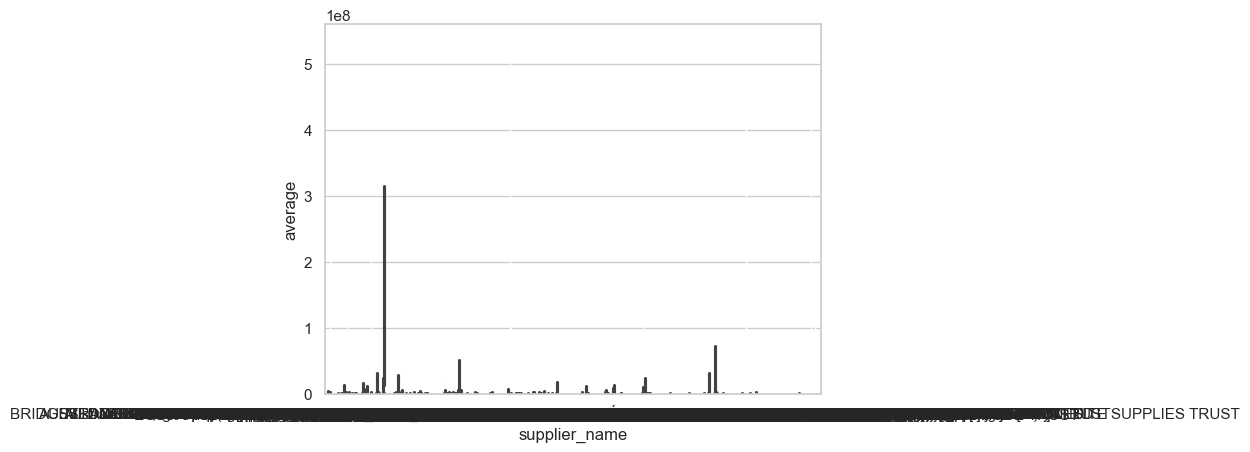

In [76]:
sns.barplot(data=category_df,x='supplier_name',y='average')
plt.show()